# Principal Component Analysis (PCA) – Evaluation Version
## Dimensionality Reduction Lab (Iris Dataset)

Instructions:
- Complete all TODO sections.
- Add explanations where requested.
- Interpret your findings clearly.
- Submit the completed notebook.


## 1. Import Required Libraries
### TODO:
- Import NumPy
- Import Pandas
- Import Matplotlib
- Import Iris dataset
- Import StandardScaler
- Import PCA
- Import train_test_split
- Import LogisticRegression
- Import accuracy_score


In [93]:
# TODO: Write your import statements here
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


## 2. Load the Iris Dataset
### TODO:
- Load the Iris dataset
- Convert features into a DataFrame
- Extract target variable
- Display dataset shape
- Display first 5 rows


In [94]:
# TODO: Load dataset here
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
target = iris.target
print(df.shape)
df.head()


(150, 4)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## 3. Standardize the Features
### TODO:
- Initialize StandardScaler
- Fit and transform features
- Print mean and standard deviation

Why is feature scaling necessary before PCA?


In [95]:
# TODO: Standardize data here
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df)
print(scaled_features.mean(axis=0))
print(scaled_features.std(axis=0))



[-1.69031455e-15 -1.84297022e-15 -1.69864123e-15 -1.40924309e-15]
[1. 1. 1. 1.]


## 4. Apply PCA
### TODO:
- Initialize PCA (without limiting components)
- Fit PCA on scaled data
- Extract explained_variance_
- Extract explained_variance_ratio_
- Print explained variance ratios

What does explained_variance_ratio_ represent?


In [96]:
# TODO: Apply PCA here
pca=PCA()
pca.fit(scaled_features)
explained_variance=pca.explained_variance_
explained_variance_ratio=pca.explained_variance_ratio_
print(explained_variance_ratio)


[0.72962445 0.22850762 0.03668922 0.00517871]


## 5. Scree Plot
### TODO:
- Plot cumulative explained variance
- Label axes properly
- Interpret how many components are sufficient
- Determine number of components that explain at least 95% variance
Print that number


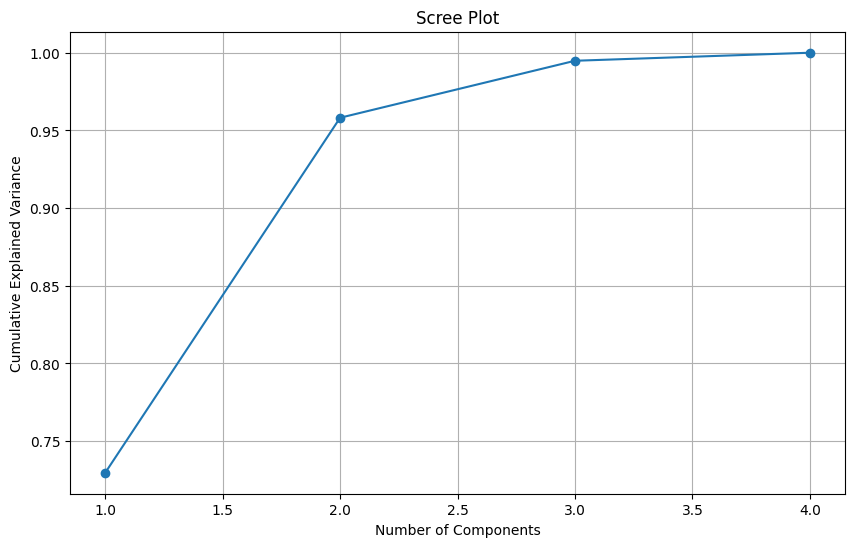

In [97]:
# TODO: Create scree plot here
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), np.cumsum(explained_variance_ratio), marker='o', linestyle='-')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot')
plt.grid(True)
plt.show()




## 6. Reduce Dataset to 2 Principal Components
### TODO:
- Initialize PCA with n_components=2
- Transform dataset
- Print total explained variance

Is dimensionality reduction effective here?


In [98]:
# TODO: Reduce dimensions here
pca=PCA(n_components=2)
reduced_features=pca.fit_transform(scaled_features)
print(pca.explained_variance_ratio_.sum())




0.9581320720000166


## 7. Visualize PCA Projection
### TODO:
- Create scatter plot of PC1 vs PC2
- Use class labels as color
- Label axes clearly

Describe class separability.


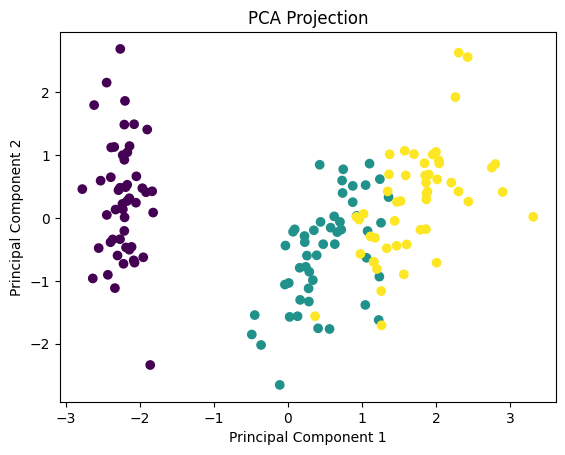

In [99]:
# TODO: Visualize PCA projection here
plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=target, cmap='viridis')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Projection')
plt.show()



## 8. Classification Before and After PCA
### TODO:
- Split original scaled dataset
- Train Logistic Regression
- Compute accuracy

- Split PCA-reduced dataset
- Train Logistic Regression
- Compute accuracy

Compare both results and explain differences.


In [100]:
# TODO: Train and evaluate model here
x_scaled_train, x_scaled_test, y_scaled_train, y_scaled_test = train_test_split(scaled_features, target, test_size=0.2, random_state=42)
model=LogisticRegression()
model.fit(x_scaled_train, y_scaled_train)
y_scaled_pred=model.predict(x_scaled_test)
accuracy_scaled=accuracy_score(y_scaled_test, y_scaled_pred)
print(f"Accuracy before PCA: {accuracy_scaled}")


x_pca_train, x_pca_test, y_pca_train, y_pca_test = train_test_split(reduced_features, target, test_size=0.2, random_state=42)
model.fit(x_pca_train, y_pca_train)
y_pca_pred=model.predict(x_pca_test)
accuracy_pca=accuracy_score(y_pca_test, y_pca_pred)
print(f"Accuracy after PCA: {accuracy_pca}")

Accuracy before PCA: 1.0
Accuracy after PCA: 0.9


## 9. Reconstruction Error
### TODO:
- Reconstruct original data from 2 components
- Compute reconstruction error (MSE)

What does reconstruction error indicate?

In [101]:
# TODO: Compute reconstruction error here
reconstructed_data=pca.inverse_transform(reduced_features)
reconstruction_error=np.mean((scaled_features - reconstructed_data) ** 2)
print(f"Reconstruction Error: {reconstruction_error}")

Reconstruction Error: 0.041867927999983595


## 10. Final Reflection
### TODO:
- What is the benefit of PCA in this dataset?
- Did PCA reduce performance?
- When is PCA most useful?
